## Create a TensorRT enginee on an existing resnet50 onnx 

```
ONNX model --> TensorRT Engine (.plan) --> infrence script --> Nsight System profiling --> Latency/GPU timeline analysis
```
# set clock 
```
!sudo nvpmodel -m 0
!sudo jetson_clocks
```

### Download existing onnx model.
Note : Some times wget may corrupt the file, in that case download directly

In [3]:
#!wget https://github.com/onnx/models/blob/main/validated/vision/classification/resnet/model/resnet50-v1-7.onnx

--2026-02-15 22:39:56--  https://github.com/onnx/models/blob/main/validated/vision/classification/resnet/model/resnet50-v1-7.onnx
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘resnet50-v1-7.onnx’

resnet50-v1-7.onnx      [ <=>                ] 192.63K  --.-KB/s    in 0.03s   

2026-02-15 22:39:57 (6.96 MB/s) - ‘resnet50-v1-7.onnx’ saved [197256]



### Verify ONNX 

In [12]:
#verify Onnx runtime

import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("./models/resnet50-v1-7.onnx")
input_name = session.get_inputs()[0]
dummy = np.random.randn(1,3,224,224).astype(np.float32)

# pirnt the name and hsape of all inputs
for input in session.get_inputs():
    print(f"Input Name : {input.name}")
    print(f"Input Shape: {input.shape}")


outputs = session.run(None, {'data': dummy})
print(f"Output shape {outputs[0].shape}")

Input Name : data
Input Shape: ['N', 3, 224, 224]
Output shape (1, 1000)


### Convert Onnx file to TensorRT Engine file

In [ ]:
# Base FP16 conversion
# onnx file location ./models/resnet50-v1-7.onnx

!/usr/src/tensorrt/bin/trtexec --onnx='./models/resnet50-v1-7.onnx' --saveEngine=./enginefiles/resnet50_fp16_engine_pytorch.plan --fp16 --verbose



In [2]:
!ls ./enginefiles/

resnet50_fp16_engine_pytorch.plan


In [28]:
# test engine infrence
! /usr/src/tensorrt/bin/trtexec --loadEngine='./enginefiles/resnet50_fp16_engine_pytorch.plan' --shapes=data:1x3x224x224 | grep "=== Performance summary ===" -A 5

#!polygraph inspect model './enginefiles/resnet50_fp16_engine_pytorch.plan' 

[02/20/2026-13:26:44] [W] [TRT] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.
[02/20/2026-13:26:47] [I] === Performance summary ===
[02/20/2026-13:26:47] [I] Throughput: 253.265 qps
[02/20/2026-13:26:47] [I] Latency: min = 2.96118 ms, max = 8.00513 ms, mean = 4.00684 ms, median = 3.23396 ms, percentile(90%) = 6.35693 ms, percentile(95%) = 6.99188 ms, percentile(99%) = 7.87021 ms
[02/20/2026-13:26:47] [I] Enqueue Time: min = 0.463623 ms, max = 1.2612 ms, mean = 0.559857 ms, median = 0.549072 ms, percentile(90%) = 0.630005 ms, percentile(95%) = 0.663696 ms, percentile(99%) = 0.74408 ms
[02/20/2026-13:26:47] [I] H2D Latency: min = 0.050293 ms, max = 0.0976562 ms, mean = 0.0590277 ms, median = 0.0579834 ms, percentile(90%) = 0.0651245 ms, percentile(95%) = 0.0687256 ms, percentile(99%) = 0.0809021 ms
[02/20/2026-13:26:47] [I] GPU Compute Time: min = 2.89844 ms, max = 7.93433 ms, mean = 3.9396 ms, me

In [39]:
# Test infrence 

import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit
import numpy as np
import time

TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
engine_file_path = './enginefiles/resnet50_fp16_engine_pytorch.plan'

#load engine/planer file
with open(engine_file_path, "rb") as f, trt.Runtime(TRT_LOGGER) as runtime:
    engine = runtime.deserialize_cuda_engine(f.read())

context = engine.create_execution_context()



# Get tensor names

input_name = None
output_name = None

for i in range(engine.num_io_tensors):
    name = engine.get_tensor_name(i)
    mode = engine.get_tensor_mode(name)
    if mode == trt.TensorIOMode.INPUT:
        input_name = name
    else:
        output_name = name

# Get shapes & dtypes from engine
input_shape = context.get_tensor_shape(input_name)
output_shape = context.get_tensor_shape(output_name)

input_dtype = trt.nptype(engine.get_tensor_dtype(input_name))
output_dtype = trt.nptype(engine.get_tensor_dtype(output_name))


#Allocate host memory
h_input = np.random.rand(*input_shape).astype(input_dtype)
h_output = np.empty(output_shape, dtype=output_dtype)

# Allocate device memory
d_input = cuda.mem_alloc(int(h_input.nbytes))
d_output = cuda.mem_alloc(int(h_output.nbytes))

# set tensor addresses 
context.set_tensor_address(input_name, int(d_input))
context.set_tensor_address(output_name, int(d_output))

stream = cuda.Stream()


#warm up 
for _ in range(10):
    cuda.memcpy_htod_async(d_input, h_input, stream)
    context.execute_async_v3(stream_handle=stream.handle)
    cuda.memcpy_dtoh_async(h_output, d_output, stream)
    stream.synchronize()
    

[02/20/2026-22:46:07] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.


In [41]:
# Timed run
import time
start_time = time.time()

for _ in range(10000):
    cuda.memcpy_htod_async(d_input, h_input, stream)
    context.execute_async_v3(stream_handle=stream.handle)
    cuda.memcpy_dtoh_async(h_output, d_output, stream)
    stream.synchronize()

end_time = time.time()

print("Avg latency : ", (end_time - start_time) / 100 * 1000, "ms")


Avg latency :  326.6390562057495 ms


In [36]:
import tensorrt as trt
trt.__version__

'10.3.0'

In [3]:
#pip install scikit-image
from skimage import io 
from skimage.transform import resize
from matplotlib import pyplot as plt
import numpy as np

url='https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg'
# resize 
img = resize(io.imread(url), (244, 244))
img = np.expand_dims(np.array(img, dtype=np.float32), axis=0) # expand imag to have a batch dimension
BATCH_SIZE = 32
input_batch = np.array(np.repeat(img, BATCH_SIZE, axis=0), dtype=np.float32)

input_batch.shape

(32, 244, 244, 3)

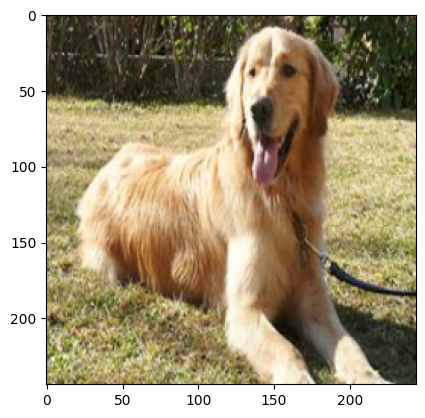

In [4]:
plt.imshow(input_batch[0].astype(np.float32))

In [9]:
# move the batch to gpu

input_batch_chw = torch.from_numpy(input_batch).transpose(1,3).transpose(2,3)
input_batch_gpu = input_batch_chw.to("cuda")

# run preduction on the batch
with torch.no_grad():
    predications = np.array(model(input_batch_gpu).cpu())
    outputs = model(input_batch_gpu)
    _, indx = torch.max(outputs, 1)

from torchvision.models import ResNet50_Weights
weights = ResNet50_Weights.DEFAULT
categories = weights.meta['categories']

print(f'Predicted Name : {categories[indx[0]]}')
predications.shape

Predicted Name : golden retriever


(32, 1000)

In [10]:
USE_FP16 = True
target_dtype = np.float16 if USE_FP16 else npfloat32
target_dtype

numpy.float16

In [11]:
# Check tensor rt insstallation
import tensorrt
if USE_FP16:
    !trtexec --onnx=resnet50_pytorch.onnx --saveEngine=